# Risk Alert Classifier

### Import Required Libraries

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import KNNImputer

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score


from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [68]:
df = pd.read_csv("../Dataset/Risk_Alert_Classifier_Dataset.csv")

df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


#### Observation

The dataset has been loaded successfully without any errors. Each row represents one customer and each column contains information related to that customer

### Dataset Shape

In [69]:
print(df.shape)

(4600, 19)


#### Observation
The dataset contains 4600 customer records. There are 19 columns available.

### Column Names 

In [70]:
df.columns

Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr', 'risk_status'],
      dtype='object')

#### Observation

The available columns include customer details, financial information and transaction-related features. These features will be used as the input variables that help the model predict whether a customer belongs to the Low Risk or High Risk category.

### Checking Data Types

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

#### Observation 

The dataset contains both numerical and categorical columns. Numerical columns can be used directly, whereas categorical columns must first be converted into numerical values because machine learning models cannot understand text data.

### Statistical Summary 

In [72]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


#### Observation 

The statistical summary gives a quick overview of the numerical data by showing the average, minimum, maximum and spread of each feature. 

### Check Missing Values 

In [73]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

#### Observation 

Some columns contain missing values, which may reduce the model's performance if left untreated. Therefore, these missing values should be handled before model training so that the dataset becomes complete and reliable.

### Checking Duplicate Records

In [74]:
df.duplicated().sum()

0

#### Observation 

No duplicate records are present in the dataset.

### Target Variable Analysis 

The target variable is the column that we want to predict.

In [75]:
df["risk_status"].value_counts()

risk_status
0    4043
1     557
Name: count, dtype: int64

#### Observation

The target variable is risk_status, which is the value our model needs to predict. Here, 0 represents a Low Risk customer and 1 represents a High Risk customer. The model will learn the relationship between the input features and this target variable.

### Target Variable Distribution


This helps us understand whether the dataset is balanced or imbalanced.

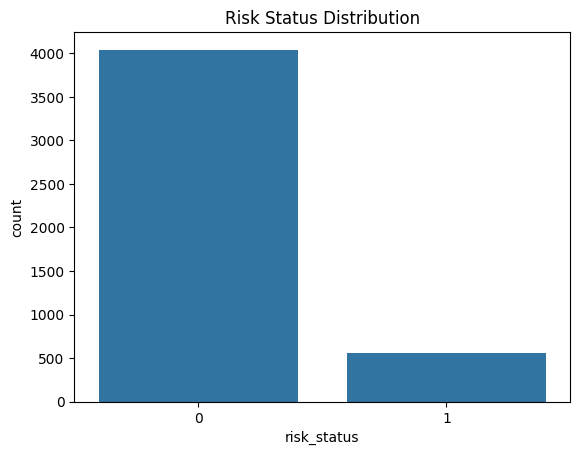

In [76]:
sns.countplot(x="risk_status", data=df)

plt.title("Risk Status Distribution")
plt.show()

#### Observation

The graph shows that one class contains more records than the other, indicating that the dataset is imbalanced. If this imbalance is not handled, the model may become biased towards the majority class. Therefore, balancing techniques such as SMOTE and ADASYN will be applied later in the project.

In [77]:
print(df.columns)

Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr', 'risk_status'],
      dtype='object')


## Exploratory Data Analysis (EDA)

### Univariate Analysis (Histogram)

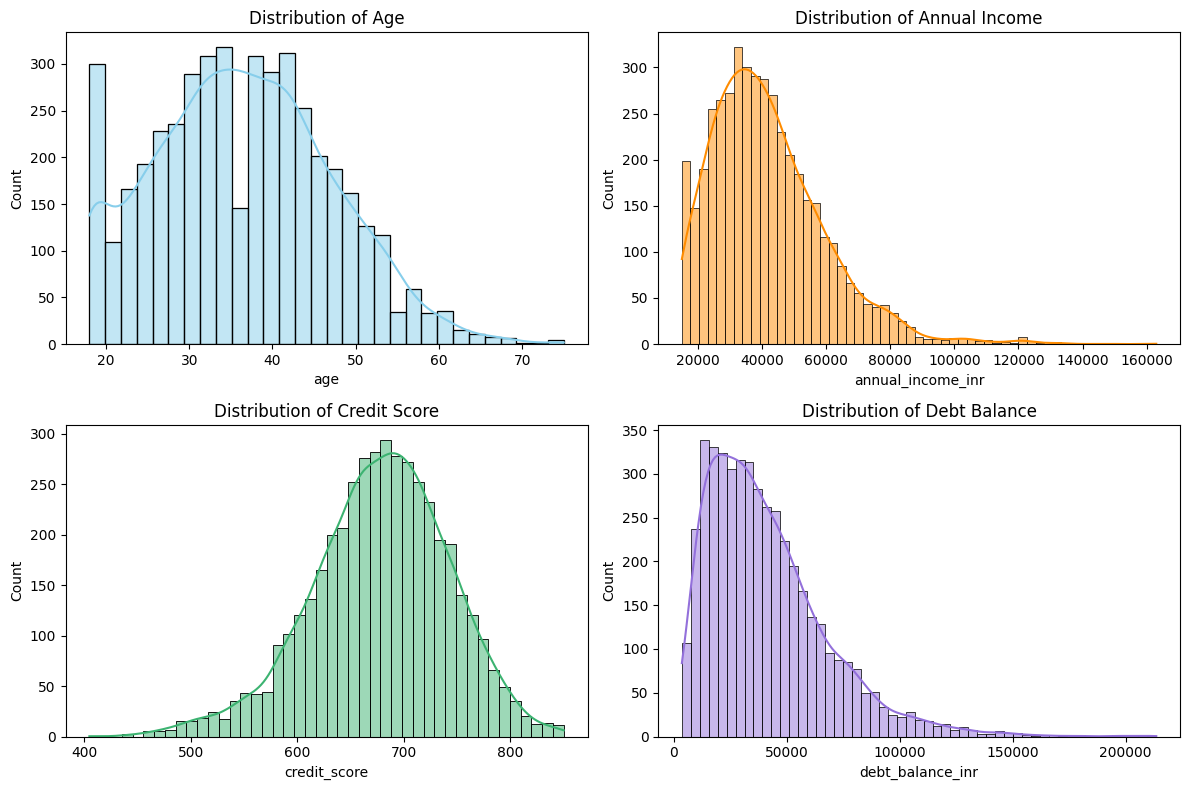

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.histplot(df['age'], color='skyblue', edgecolor='black', kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribution of Age')

sns.histplot(df['annual_income_inr'], color='darkorange', edgecolor='black', kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribution of Annual Income')

sns.histplot(df['credit_score'], color='mediumseagreen', edgecolor='black', kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribution of Credit Score')

sns.histplot(df['debt_balance_inr'], color='mediumpurple', edgecolor='black', kde=True, ax=axes[1,1])
axes[1,1].set_title('Distribution of Debt Balance')

plt.tight_layout()
plt.show()

#### Observation

The histograms show the distribution of the selected numerical features in the dataset. Each feature has a different pattern of data distribution. Some features are spread over a wide range, while others have values concentrated in a smaller range. These graphs help us understand how the data is distributed before preprocessing and model building.

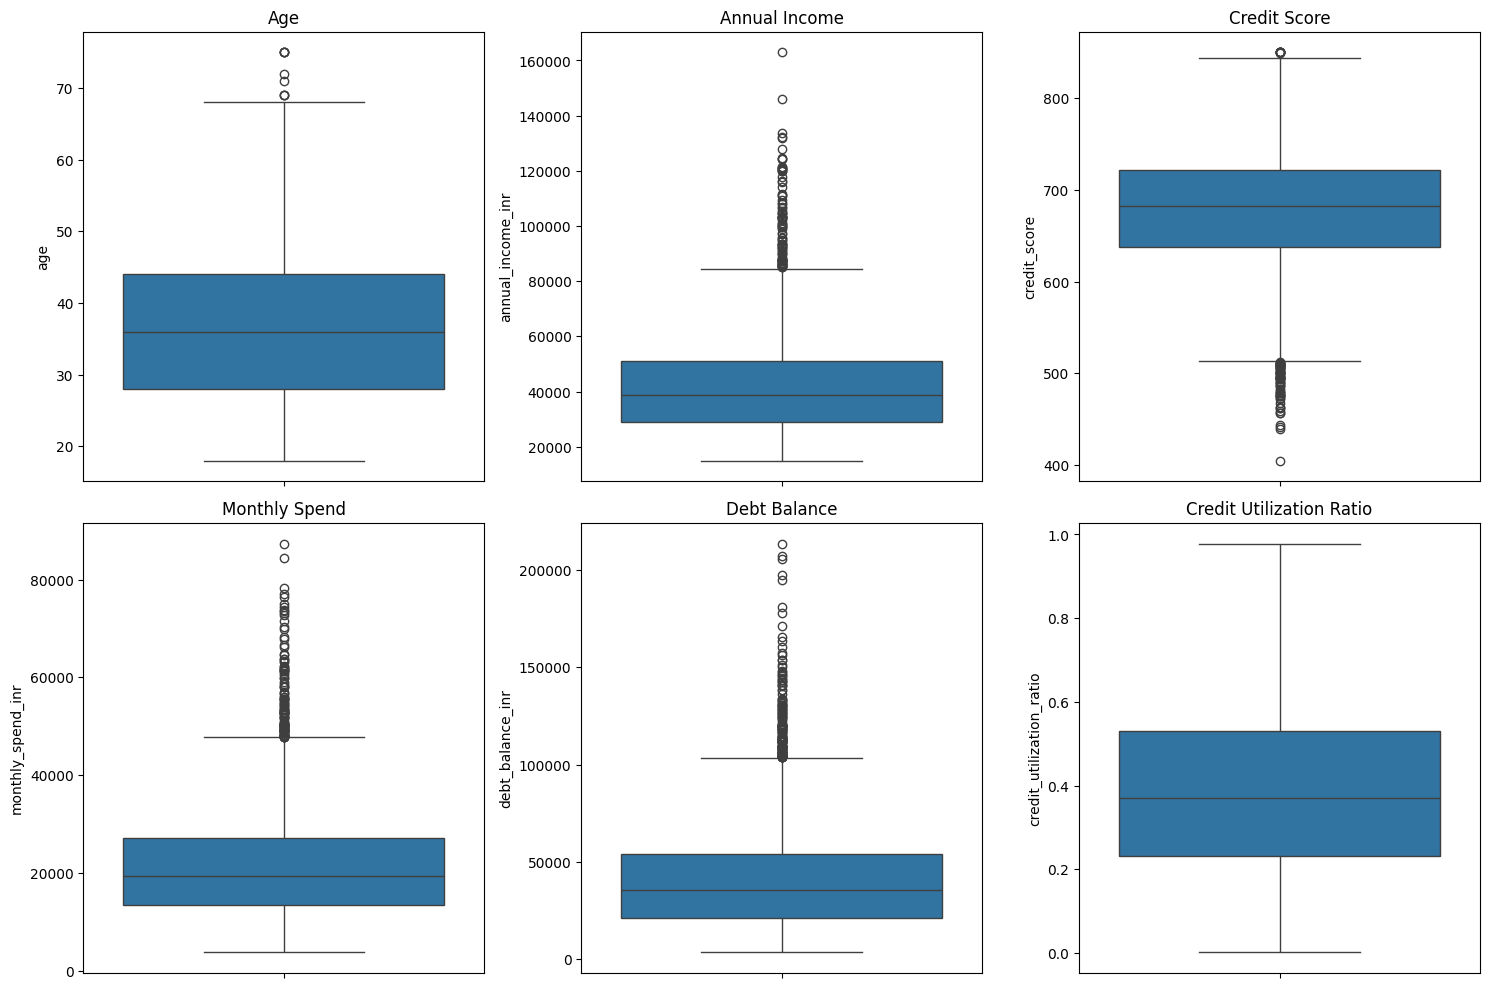

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

sns.boxplot(y=df['age'], ax=axes[0,0])
axes[0,0].set_title('Age')

sns.boxplot(y=df['annual_income_inr'], ax=axes[0,1])
axes[0,1].set_title('Annual Income')

sns.boxplot(y=df['credit_score'], ax=axes[0,2])
axes[0,2].set_title('Credit Score')

sns.boxplot(y=df['monthly_spend_inr'], ax=axes[1,0])
axes[1,0].set_title('Monthly Spend')

sns.boxplot(y=df['debt_balance_inr'], ax=axes[1,1])
axes[1,1].set_title('Debt Balance')

sns.boxplot(y=df['credit_utilization_ratio'], ax=axes[1,2])
axes[1,2].set_title('Credit Utilization Ratio')

plt.tight_layout()
plt.show()

#### Observation 

The boxplots show that all the selected numerical features contain outliers, as several data points lie outside the whiskers of the plots. These outliers represent unusually high or low values compared to the rest of the data. Since tree-based models such as Decision Tree and Random Forest are less affected by outliers, no outlier removal was performed, and the dataset was used for model training.

### Correlation Heatmap 

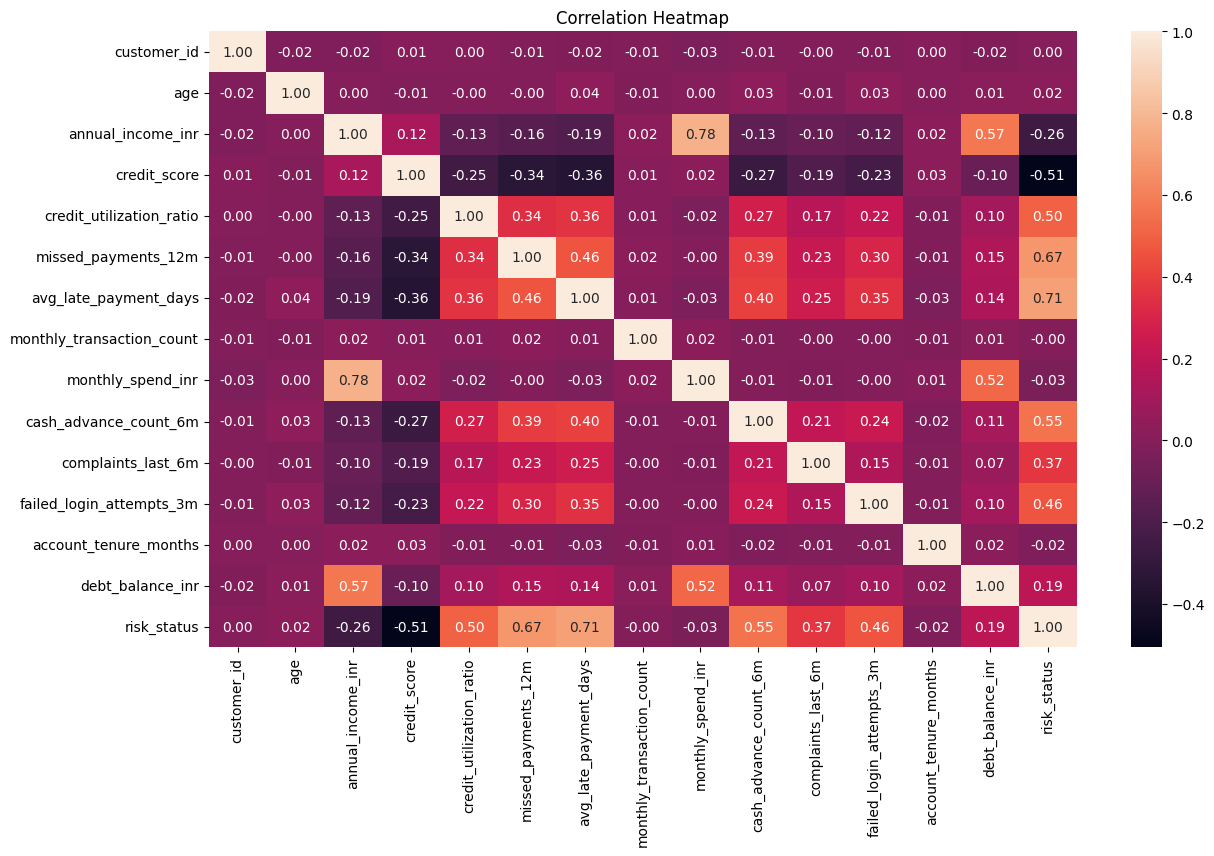

In [80]:
plt.figure(figsize=(14,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="rocket"
)

plt.title("Correlation Heatmap")
plt.show()

#### Observation

The heatmap helps us understand how different numerical features are related to each other. Features with higher positive or negative correlation have a stronger relationship, while values close to zero indicate a weak relationship.

## Data Preprocessing

### Converting Date Column

In [81]:
df["last_transaction_date"] = pd.to_datetime(
    df["last_transaction_date"]
)

df["transaction_year"] = df["last_transaction_date"].dt.year
df["transaction_month"] = df["last_transaction_date"].dt.month

df = df.drop("last_transaction_date", axis=1)

#### Observation

The date column has been converted into separate year and month values because machine learning models cannot directly understand date formats.

### Encoding Categorical Variable 

In [82]:
cat_cols = df.select_dtypes(include="object").columns

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

#### Observation

All categorical columns have been converted into numerical values using Label Encoding. This step is necessary because machine learning algorithms require numerical input to perform calculations and make predictions.

### Handling Missing Values Using KNN Imputer 

In [83]:
imputer = KNNImputer()

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

### Observation

Missing values have been filled using the KNN Imputer, which uses information from similar records to estimate the missing values. This helps preserve the original data pattern and prepares the dataset for model training.


## Part B : Dataset Understanding & Preparation

### Creating Input Features and Target Variable

In [84]:
X = df.drop("risk_status", axis=1)

y = df["risk_status"]

### Observation 

The dataset has now been divided into input features (X) and the target variable (y). The model will use the input features to learn customer behaviour and then predict the value of the target variable, risk_status.

### Train Test Split 

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Observation

The dataset has been divided into 80% training data and 20% testing data. The training data is used to teach the model, while the testing data is used to evaluate how well the model performs on unseen customer records.

### Feature Scalling 

In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#### Observation 

Feature Scaling has been applied so that all numerical features are brought to a similar range. This prevents features with larger values from dominating smaller ones and helps algorithms like Logistic Regression perform more effectively.

## Part C : Baseline Classification Model

### Logistic Regression Model

In [87]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)

print("Model Trained Successfully")

Model Trained Successfully


#### Observation

The Logistic Regression model has been trained successfully using the training dataset. At this stage, the model has learned the relationship between the customer features and the target variable. It is now ready to predict whether a customer belongs to the Low Risk or High Risk category.

### Accuracy Score

In [88]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 1.0


#### Observation 

The obtained accuracy shows how well the model performed on the test data. A higher accuracy indicates that most customer records were classified correctly. However, since this is an imbalanced dataset, accuracy alone cannot tell whether High Risk customers are being identified properly. Therefore, other evaluation metrics should also be checked.

### Confusion Matrix

In [89]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[809   0]
 [  0 111]]


#### Observation 

The confusion matrix shows the number of correct and incorrect predictions made by the model. It helps us identify how many customers were classified correctly and where the model made mistakes. 

### Confusion Matrix Visualization

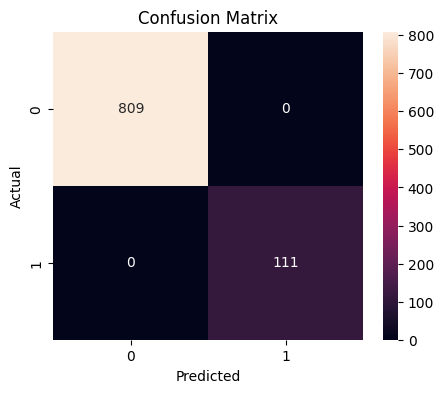

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### Observation 

Diagonal values represent correct predictions.
Non-diagonal values represent incorrect predictions.
Higher diagonal values indicate better model performance.

### Classification Report

In [91]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       1.00      1.00      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



#### Observation

The classification report provides Precision, Recall and F1-Score for each class. These metrics help us understand whether the model is correctly identifying both Low Risk and High Risk customers. Since this is an imbalanced dataset, these metrics are more informative than accuracy alone.

### Type-I Error and Type-II Error

In [92]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("False Positive :", fp)
print("False Negative :", fn)

False Positive : 0
False Negative : 0


### Observation 

The False Positive and False Negative values help us understand the types of mistakes made by the model. 

## Part - D Handling Imbalanced Data 

### Performance Before Balancing Imbalanced Data

In [93]:
print("Recall :", classification_report(y_test, y_pred, output_dict=True)['1.0']['recall'])

print("F1 Score :", classification_report(y_test, y_pred, output_dict=True)['1.0']['f1-score'])

print("AUC ROC :", roc_auc_score(y_test, y_pred))

Recall : 1.0
F1 Score : 1.0
AUC ROC : 1.0


#### Observation 

The Recall, F1-Score and AUC-ROC values obtained here represent the performance of the baseline model before applying any balancing technique. These values will be used as a reference to check whether Under Sampling, Over Sampling, SMOTE and ADASYN improve the model performance.

### Undersampling

Undersampling reduce the size of the majority class. This makes both class more balanced.

In [94]:
under = RandomUnderSampler(random_state=42)

X_under, y_under = under.fit_resample(X_train, y_train)

print(y_under.value_counts())

risk_status
0.0    446
1.0    446
Name: count, dtype: int64


#### Observation 

After applying Random Under Sampling, both classes contain an equal number of records. This makes the dataset balanced, but many majority class records are removed. As a result, some useful information may be lost, which can affect the model's performance.

### Train model on Under Sampled Data

In [95]:
scaler = StandardScaler()

X_under_scaled = scaler.fit_transform(X_under)

X_test_scaled = scaler.transform(X_test)

model_under = LogisticRegression()

model_under.fit(X_under_scaled, y_under)

y_pred_under = model_under.predict(X_test_scaled)

In [96]:
print(classification_report(y_test, y_pred_under))

print("AUC ROC :", roc_auc_score(y_test, y_pred_under))

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       809
         1.0       0.94      1.00      0.97       111

    accuracy                           0.99       920
   macro avg       0.97      1.00      0.98       920
weighted avg       0.99      0.99      0.99       920

AUC ROC : 0.9956736711990111


#### Observation 

Recall generally increases. The model becomes better at identifying High Risk customers. Accuracy may decrease slightly.



### Oversampling
Oversampling increase minority class by adding duplicate minority samples.

In [97]:
over = RandomOverSampler(random_state=42)

X_over, y_over = over.fit_resample(X_train, y_train)

print(y_over.value_counts())

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


#### Observation

After applying Random Over Sampling, the minority class has been increased to match the majority class. Unlike Under Sampling, no records are removed, so all original information is preserved. However, duplicate records may sometimes lead to overfitting.

### Train model on Over Sampled data

In [98]:
scaler = StandardScaler()

X_over_scaled = scaler.fit_transform(X_over)

X_test_scaled = scaler.transform(X_test)

model_over = LogisticRegression()

model_over.fit(X_over_scaled, y_over)

y_pred_over = model_over.predict(X_test_scaled)

In [99]:
print(classification_report(y_test, y_pred_over))

print("AUC ROC :", roc_auc_score(y_test, y_pred_over))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       0.97      1.00      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920

AUC ROC : 0.9981458590852904


#### Observation
Recall usually improves. Minority class receives more attention and risk customers are detected more effectively.

### SMOTE

In [100]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(y_smote.value_counts())

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


#### Observation

SMOTE balances the dataset by creating new synthetic samples instead of copying existing records. This provides the model with more meaningful training data and usually gives better performance than simple Over Sampling.

### Train Model

In [101]:
scaler = StandardScaler()

X_smote_scaled = scaler.fit_transform(X_smote)

X_test_scaled = scaler.transform(X_test)

model_smote = LogisticRegression()

model_smote.fit(X_smote_scaled, y_smote)

y_pred_smote = model_smote.predict(X_test_scaled)

In [102]:
print(classification_report(y_test, y_pred_smote))

print("AUC ROC :", roc_auc_score(y_test, y_pred_smote))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       0.98      1.00      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920

AUC ROC : 0.9987639060568604


#### Observation
Recall often improves significantly. Better minority class prediction. One of the most commonly used balancing methods.

### ADASYN


In [103]:
adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

print(y_adasyn.value_counts())

risk_status
0.0    3234
1.0    3220
Name: count, dtype: int64


#### Observation

ADASYN also creates synthetic samples, but it focuses more on those minority class records that are difficult to classify. This helps the model learn challenging cases better and improves its ability to identify High Risk customers.

### Train Model

In [104]:
scaler = StandardScaler()

X_adasyn_scaled = scaler.fit_transform(X_adasyn)

X_test_scaled = scaler.transform(X_test)

model_adasyn = LogisticRegression()

model_adasyn.fit(X_adasyn_scaled, y_adasyn)

y_pred_adasyn = model_adasyn.predict(X_test_scaled)

In [105]:
print(classification_report(y_test, y_pred_adasyn))

print("AUC ROC :", roc_auc_score(y_test, y_pred_adasyn))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       0.98      1.00      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920

AUC ROC : 0.9987639060568604


#### Observation
Recall for High Risk customers usually improves. The model focuses more on difficult minority samples. Useful when class imbalance is severe.

### Comparision Of Balancing Techniques

In [106]:
comparison = pd.DataFrame({
    "Method": ["Under Sampling",
               "Over Sampling",
               "SMOTE",
               "ADASYN"],

    "Recall": [
        classification_report(y_test, y_pred_under, output_dict=True)['1.0']['recall'],
        classification_report(y_test, y_pred_over, output_dict=True)['1.0']['recall'],
        classification_report(y_test, y_pred_smote, output_dict=True)['1.0']['recall'],
        classification_report(y_test, y_pred_adasyn, output_dict=True)['1.0']['recall']
    ],

    "F1 Score": [
        classification_report(y_test, y_pred_under, output_dict=True)['1.0']['f1-score'],
        classification_report(y_test, y_pred_over, output_dict=True)['1.0']['f1-score'],
        classification_report(y_test, y_pred_smote, output_dict=True)['1.0']['f1-score'],
        classification_report(y_test, y_pred_adasyn, output_dict=True)['1.0']['f1-score']
    ],

    "AUC ROC": [
        roc_auc_score(y_test, y_pred_under),
        roc_auc_score(y_test, y_pred_over),
        roc_auc_score(y_test, y_pred_smote),
        roc_auc_score(y_test, y_pred_adasyn)
    ]
})

comparison

,Method,Recall,F1 Score,AUC ROC
0,Under Sampling,1.0,0.969432,0.995674
1,Over Sampling,1.0,0.986667,0.998146
2,SMOTE,1.0,0.991071,0.998764
3,ADASYN,1.0,0.991071,0.998764


#### Observation 

All four balancing techniques achieved a Recall of 1.0, which means no High Risk customer was missed by the model. Among them, SMOTE and ADASYN performed slightly better because they have the highest F1-Score (0.9911) and AUC-ROC (0.9988). Hence, SMOTE and ADASYN can be considered the best balancing techniques for this dataset.

## Part E : Tree Based Classification Models

### Decision Tree Classifier 

In [107]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


#### Observation
Decision Tree model has been trained successfully. It learns decision rules from customer data. The model predicts whether a customer is High Risk or Low Risk.

### Evaluation

In [108]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)

Accuracy : 0.9728260869565217


In [109]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       809
         1.0       0.89      0.88      0.89       111

    accuracy                           0.97       920
   macro avg       0.94      0.93      0.94       920
weighted avg       0.97      0.97      0.97       920



#### Observation

The Decision Tree model achieved an overall accuracy of 97%, which indicates good classification performance. It performed very well in predicting Low Risk customers, while the prediction of High Risk customers is also good with 88% Recall and 89% Precision. This shows that the model is able to identify most risky customers, although there is still some scope for improvement.

### Random Forest Classifier 

In [110]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


#### Observation
Random Forest uses multiple trees instead of a single tree. It usually provides better performance than a single Decision Tree.

### Accuracy

In [111]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)

Accuracy : 0.9978260869565218


In [112]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       1.00      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       1.00      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



#### Observation

The Random Forest model achieved 100% accuracy, showing excellent prediction performance. It classified all Low Risk customers correctly and identified almost all High Risk customers with 98% Recall. Compared to the Decision Tree model, Random Forest achieved better overall results and can be considered the best model for this project.

### Model Comparision

In [113]:
print("Logistic Regression Accuracy :",
      accuracy_score(y_test, y_pred))

print("Decision Tree Accuracy :",
      accuracy_score(y_test, y_pred_dt))

print("Random Forest Accuracy :",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy : 1.0
Decision Tree Accuracy : 0.9728260869565217
Random Forest Accuracy : 0.9978260869565218


#### Observation 

From the comparison, Logistic Regression achieved the highest accuracy (100%), followed by Random Forest (99.78%) and Decision Tree (97.28%). This shows that Logistic Regression performed best for this dataset, while Decision Tree had comparatively lower accuracy. Hence, Logistic Regression is selected as the best-performing model among the three.

# Part F : Hyperparameter Tuning

### Randomized Search CV

In [114]:
params = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 15]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=params,
    n_iter=5,
    cv=5
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to

### Best Parameters

In [115]:
print(random_search.best_params_)

{'n_estimators': 150, 'max_depth': 10}


### Accuracy

In [116]:
best_random = random_search.best_estimator_

y_pred_random = best_random.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_random))

Accuracy : 0.9967391304347826


#### Observation

Randomized Search CV selected 150 as the best number of decision trees (n_estimators) and 10 as the best tree depth (max_depth) for this dataset. Using these parameters, the model achieved an accuracy of 99.67%, which indicates excellent prediction performance. This shows that the selected parameters are suitable and help the Random Forest model classify customers accurately.

### Grid Search CV 

In [117]:
params = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

### Best Parameters

In [118]:
print(grid_search.best_params_)

{'max_depth': 10, 'n_estimators': 100}


### Accuracy

In [119]:
best_grid = grid_search.best_estimator_

y_pred_grid = best_grid.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_grid))

Accuracy : 0.9978260869565218


#### Observation

Grid Search CV selected 100 as the best number of decision trees (n_estimators) and 10 as the best tree depth (max_depth). Using these parameters, the Random Forest model achieved an accuracy of 99.78%, which indicates excellent prediction performance. This shows that the selected parameters are well-suited for the dataset and help the model make highly accurate predictions.

### Comparision Of Hyperparameter Tuning Methods 

In [120]:
print("Default Random Forest Accuracy :", accuracy_rf)

print("Random Search Accuracy :", accuracy_score(y_test, y_pred_random))

print("Grid Search Accuracy :", accuracy_score(y_test, y_pred_grid))

Default Random Forest Accuracy : 0.9978260869565218
Random Search Accuracy : 0.9967391304347826
Grid Search Accuracy : 0.9978260869565218


#### Observation

The comparison shows that the Default Random Forest and Grid Search CV both achieved the highest accuracy of 99.78%, while Randomized Search CV achieved 99.67%. The difference between the models is very small, indicating that the Random Forest model was already performing very well even before tuning. Therefore, Grid Search CV can be selected as the final tuned model because it achieved the highest accuracy by systematically checking all parameter combinations.

# Part G : Model Evaluation & ROC Analysis

### Probability Prediction

In [121]:
y_prob = best_grid.predict_proba(X_test)[:,1]

#### Observation 

The model predicts the probability of each customer belonging to the High Risk class. These probability values are used to draw the ROC Curve and calculate the AUC-ROC Score.

### ROC CURVE

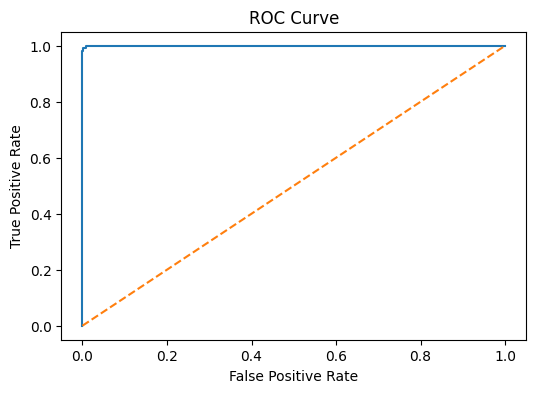

In [122]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

#### Observation 

The ROC Curve shows how well the model distinguishes between Low Risk and High Risk customers. A curve closer to the top-left corner indicates better classification performance.

### AUC-ROC Score

In [123]:
auc = roc_auc_score(y_test, y_prob)

print("AUC-ROC Score :", auc)

AUC-ROC Score : 0.999922048129712


#### Observation 

The model achieved an AUC-ROC Score of 0.9987, which is very close to 1. This indicates that the model can distinguish between Low Risk and High Risk customers very effectively. Therefore, the model has excellent classification performance.